In [48]:
import pandas as pd
df = pd.read_parquet("subgroup_analysis_final.parquet", engine="pyarrow")
df = df.rename(columns=lambda c: c.replace("_hate","").replace("identity_word","").replace("_","") 
               if c.startswith("_hate") and c.endswith("identity_word") else c)

In [19]:
%config InlineBackend.figure_format = 'retina' 

**Set Up**

In [26]:
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
import matplotlib.pyplot as plt

TARGET = "identity_hate"

PRED_COLS = [
    "TFIDFPrediction",
    "TransformerPrediction"
]

IDENTITY_COLS = [c for c in df.columns 
                 if df[c].dropna().isin([0,1]).all() 
                 and c not in [TARGET, "sentiment_score"] + PRED_COLS + ["EngineeredPrediction"]]

**Fairness Matrix**

In [41]:
def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "FPR": fp / (fp + tn) if (fp + tn) else 0,
        "FNR": fn / (fn + tp) if (fn + tp) else 0
    }

fairness = []

for model in PRED_COLS:
    for group in IDENTITY_COLS:
        subset = df[df[group] == 1]
        if len(subset) == 0:
            continue
        
        m = compute_metrics(subset[TARGET], subset[model])
        m["model"] = model
        m["group"] = group
        fairness.append(m)

fairness_df = pd.DataFrame(fairness)


In [50]:
fairness_df["FPR (%)"] = (fairness_df["FPR"] * 100).round().astype(int)
fairness_df["FNR (%)"] = (fairness_df["FNR"] * 100).round().astype(int)

fpr_table = fairness_df.pivot(index="model", columns="group", values="FPR (%)")
fnr_table = fairness_df.pivot(index="model", columns="group", values="FNR (%)")

print("\n False Positive Rate (%)")
print(fpr_table)
fpr_table.to_excel('fpr_output.xlsx', index=True)
print("\n False Negative Rate (%)")
print(fnr_table)
fnr_table.to_excel('fnr_output.xlsx', index=True)


 False Positive Rate (%)
group                  Asian  Black  Christian  Disabled  Female  Gay  \
model                                                                   
TFIDFPrediction            2     10          1         7       8   38   
TransformerPrediction      0      2          0         0       1   12   

group                  Immigrant  Jewish  Latino  Lesbian  Male  Muslim  \
model                                                                     
TFIDFPrediction                1      13       4       26     3       6   
TransformerPrediction          0       2       1        3     0       0   

group                  Trans  White  
model                                
TFIDFPrediction            5      7  
TransformerPrediction      5      1  

 False Negative Rate (%)
group                  Asian  Black  Christian  Disabled  Female  Gay  \
model                                                                   
TFIDFPrediction           35     15         50        41

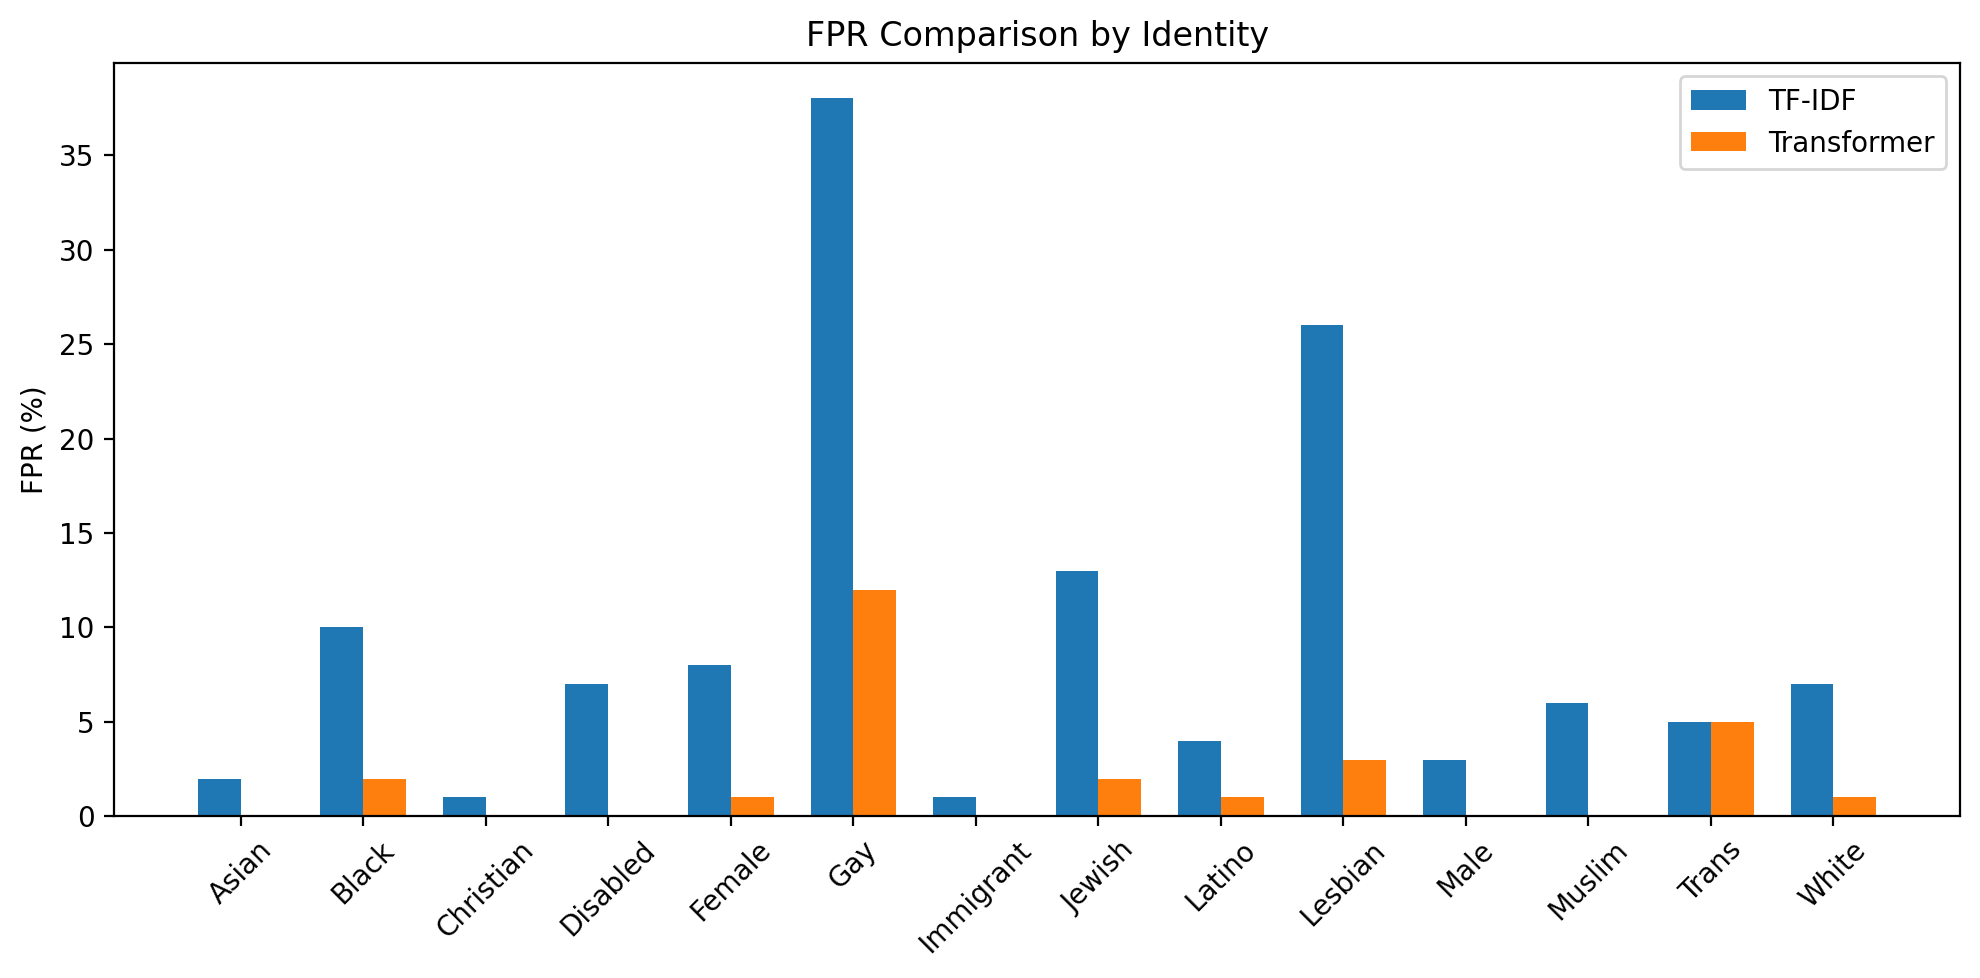

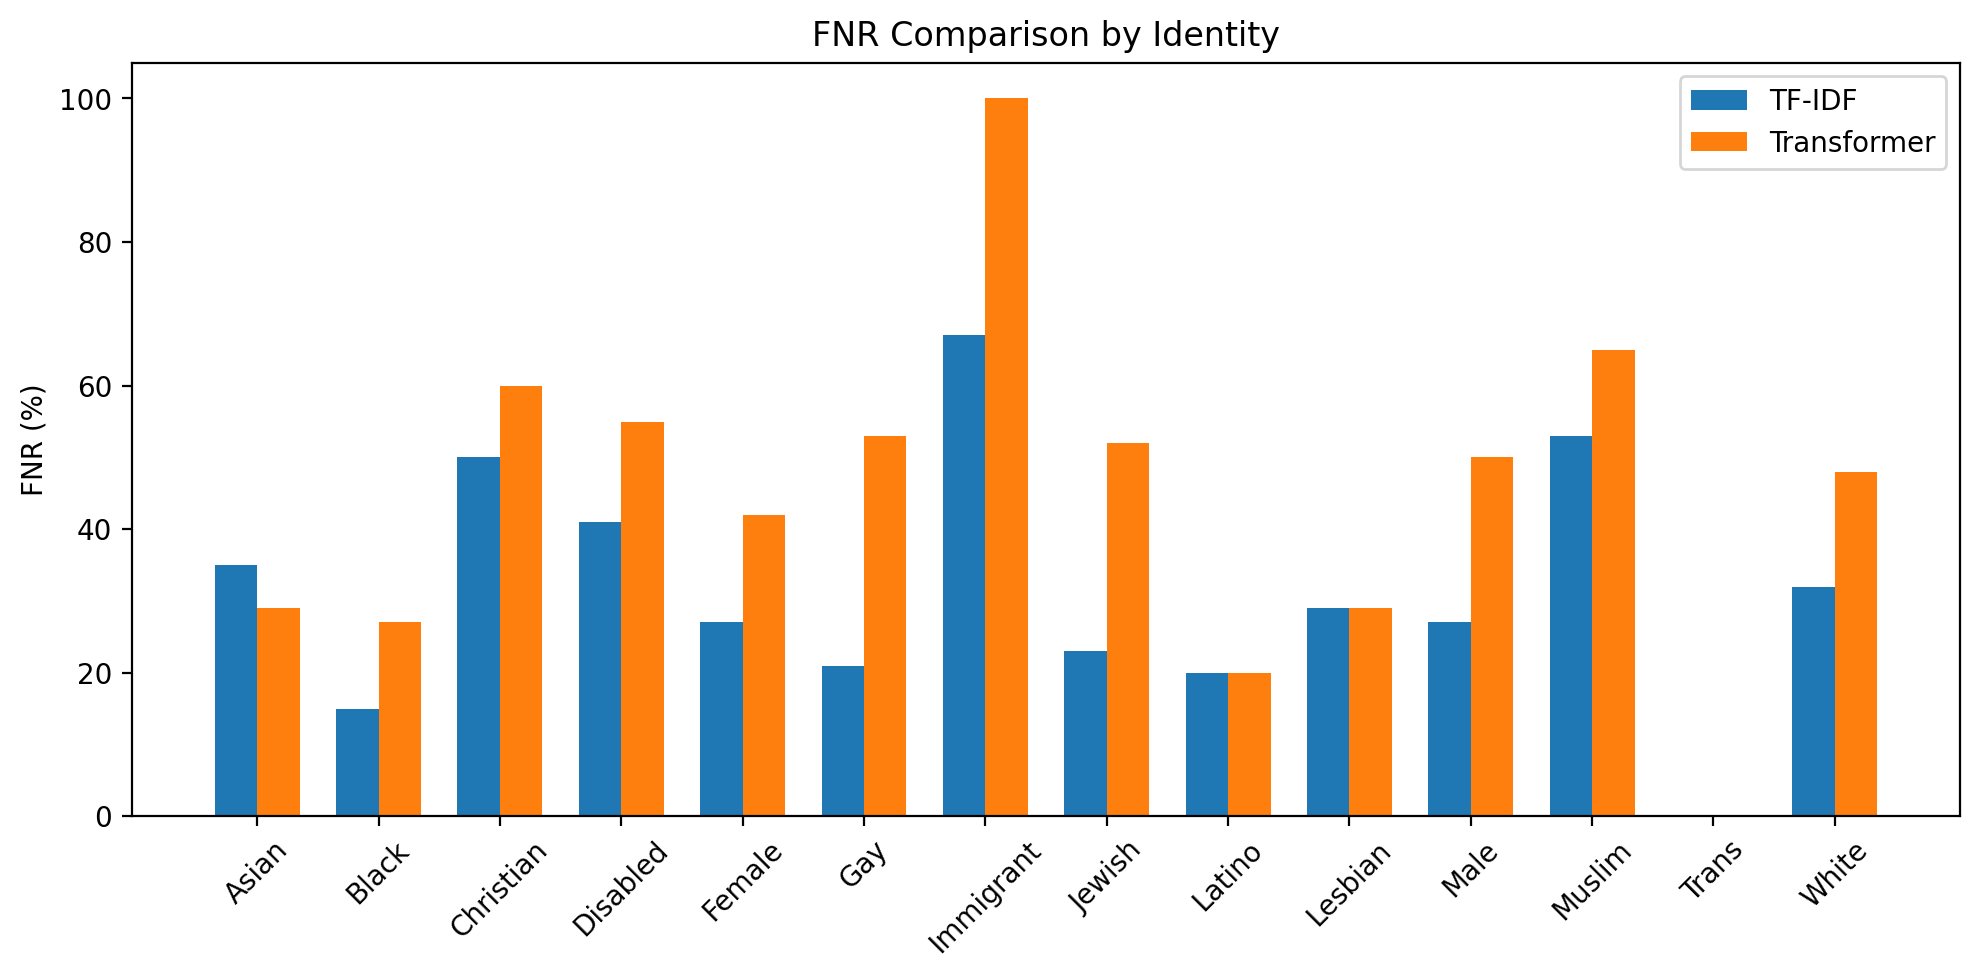

In [52]:
# keep just TF-IDF and Transformer if needed
plot_df = fairness_df[fairness_df["model"].isin(["TFIDFPrediction", "TransformerPrediction"])].copy()

# consistent identity order
groups = sorted(plot_df["group"].unique())
x = np.arange(len(groups))
width = 0.35

# values in matching order
FPR_tfidf = plot_df[plot_df["model"] == "TFIDFPrediction"].set_index("group").reindex(groups)["FPR (%)"]
FPR_trans = plot_df[plot_df["model"] == "TransformerPrediction"].set_index("group").reindex(groups)["FPR (%)"]

fnr_tfidf = plot_df[plot_df["model"] == "TFIDFPrediction"].set_index("group").reindex(groups)["FNR (%)"]
fnr_trans = plot_df[plot_df["model"] == "TransformerPrediction"].set_index("group").reindex(groups)["FNR (%)"]

# FPR comparison
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, FPR_tfidf, width, label="TF-IDF")
plt.bar(x + width/2, FPR_trans, width, label="Transformer")
plt.xticks(x, groups, rotation=45)
plt.ylabel("FPR (%)")
plt.title("FPR Comparison by Identity")
plt.legend()
plt.tight_layout()
plt.savefig("FPR.jpg")
plt.show()


# FNR comparison
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, fnr_tfidf, width, label="TF-IDF")
plt.bar(x + width/2, fnr_trans, width, label="Transformer")
plt.xticks(x, groups, rotation=45)
plt.ylabel("FNR (%)")
plt.title("FNR Comparison by Identity")
plt.legend()
plt.tight_layout()
plt.savefig("FNR.jpg")
plt.show()
